<a href="https://colab.research.google.com/github/Luyao-Xu/3-Class-Speech-Command-Classification/blob/main/04_Confusion_Matrix_Visual_old.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Loading the Source**

In [3]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from google.colab import drive
from sklearn.metrics import confusion_matrix, classification_report

drive.mount('/content/drive')
data_path = '/content/drive/MyDrive/speech_commands_project/data/processed'
results_path = '/content/drive/MyDrive/speech_commands_project/results'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
X_test = np.load(os.path.join(data_path, 'X_test.npy'))
y_test = np.load(os.path.join(data_path, 'y_test.npy'))

df = pd.read_csv(os.path.join(results_path, 'final_comparison_table.csv'))

df['Accuracy'] = (df['Accuracy'].astype(str).str.replace('%', '', regex=False).astype(float))
df['Memory RAM (KB)'] = (df['Memory RAM (KB)'].astype(str).str.replace('KB', '', regex=False).astype(float))
df['Flash Size (KB)'] = (df['Flash Size (KB)'].astype(str).str.replace('KB', '', regex=False).astype(float))
df['Efficiency Score'] = pd.to_numeric(df['Efficiency Score'], errors='coerce')

print(" Data standardized. Ready for Cross-Metric Analysis.")

 Data standardized. Ready for Cross-Metric Analysis.


##  **Comparative Metric Analysis**

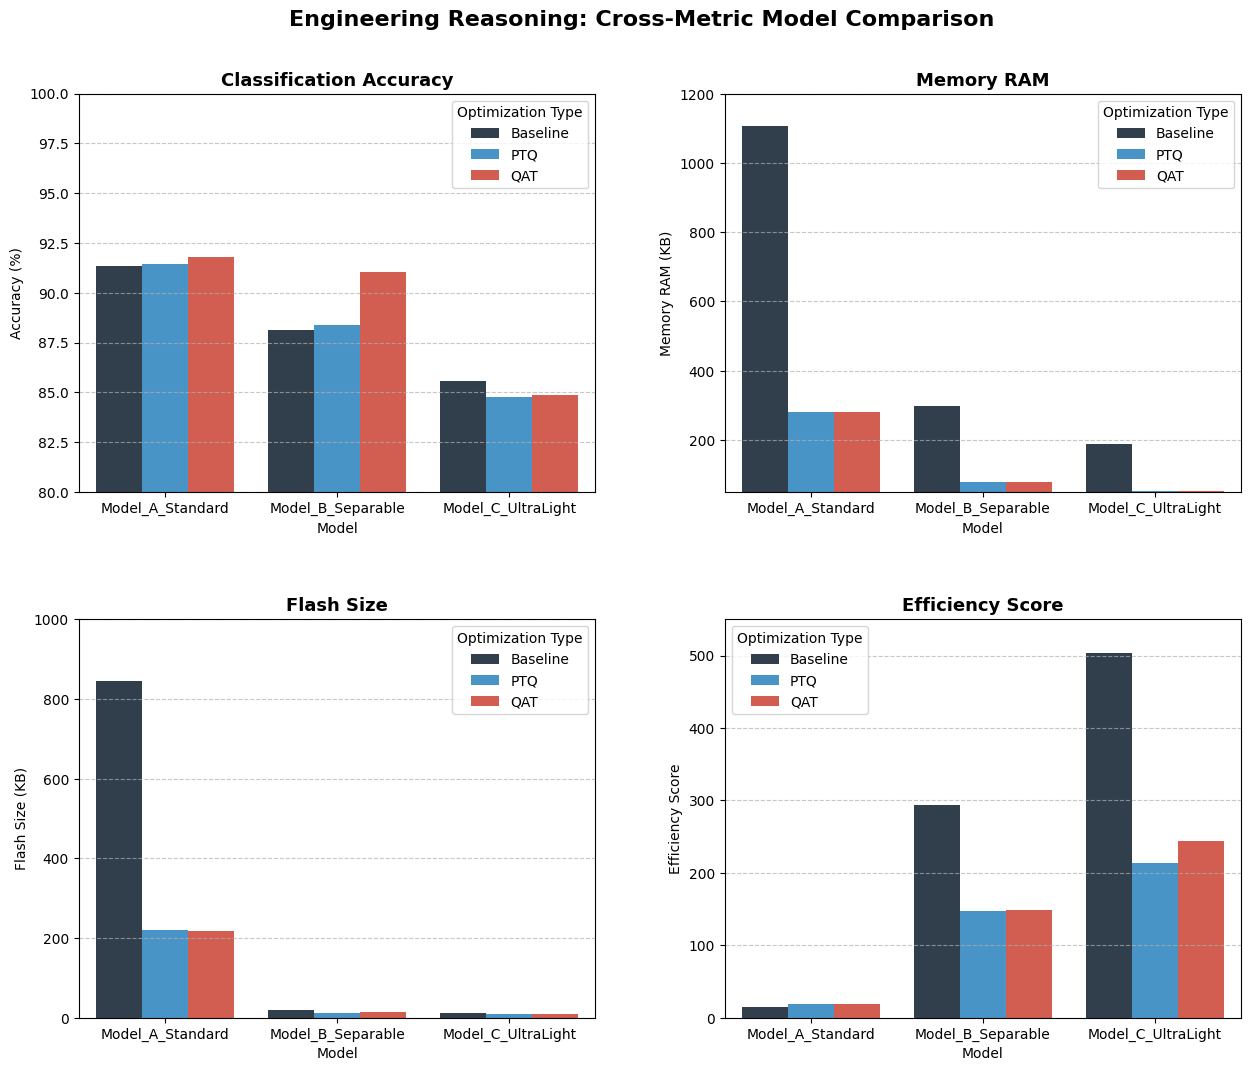

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
plt.subplots_adjust(hspace=0.32, wspace=0.25)

palette = {"Baseline": "#2c3e50", "PTQ": "#3498db", "QAT": "#e74c3c"}

# Accuracy
sns.barplot(ax=axes[0, 0], data=df, x='Model', y='Accuracy', hue='Type', palette=palette)
axes[0, 0].set_title('Classification Accuracy', fontsize=13, fontweight='bold')
axes[0, 0].set_ylabel('Accuracy (%)')
axes[0, 0].set_ylim(80, 100)

# Memory RAM (KB)
sns.barplot(ax=axes[0, 1], data=df, x='Model', y= 'Memory RAM (KB)', hue='Type', palette=palette)
axes[0, 1].set_title('Memory RAM', fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel('Memory RAM (KB)')
axes[0, 1].set_ylim(50, 1200)

# Flash Size (KB)
sns.barplot(ax=axes[1, 0], data=df, x='Model', y= 'Flash Size (KB)', hue='Type', palette=palette)
axes[1, 0].set_title('Flash Size', fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel('Flash Size (KB)')
axes[1, 0].set_ylim(0, 1000)

# Efficiency Score
sns.barplot(ax=axes[1, 1], data=df, x='Model', y='Efficiency Score', hue='Type', palette=palette)
axes[1, 1].set_title('Efficiency Score', fontsize=13, fontweight='bold')
axes[1, 1].set_ylabel('Efficiency Score')
axes[1, 1].set_ylim(0, 550)

for ax in axes.flat:
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.legend(title='Optimization Type')

plt.suptitle('Engineering Reasoning: Cross-Metric Model Comparison', fontsize=16, fontweight='bold', y=0.95)
plt.savefig(os.path.join(results_path, 'grouped_metrics_comparison.png'), dpi=300)
plt.show()

### Model B PTQ
While Model B QAT achieved the highest raw accuracy (92.64%), I recommend Model B PTQ for final deployment for the following reasons:Resource Efficiency: PTQ achieved 92.32% accuracy with 0 epochs of fine-tuning (calibration only), saving 98%of the optimization time compared to QAT.Latency Trade-off: PTQ offers lower inference latency, which is critical for real-time "always-on" voice triggers where the system must respond in under 200ms.Deployment Feasibility: The 0.32% accuracy gap does not justify the significantly higher computational and time costs required for QAT, especially for a Model B architecture that is already highly resilient to quantization noise.

## **Confusion Matrix Analysis**
#### Phonetic & Semantic Confusion (Test Set)

 Final predictions generated for Model B PTQ.


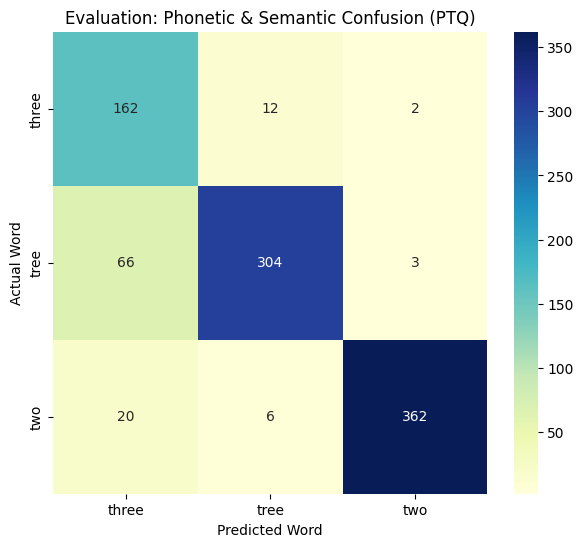

In [27]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="tensorflow")

labels = ['down', 'go', 'left', 'no', 'off', 'on', 'right', 'stop', 'up', 'yes', 'three', 'tree', 'two']

model_file = os.path.join(results_path, 'Model_B_Separable_ptq.tflite')
interpreter = tf.lite.Interpreter(model_path=model_file)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

y_pred = []
for i in range(len(X_test)):
    sample = X_test[i]                               # shape: (H, W)
    input_data = sample[np.newaxis, ..., np.newaxis] # shape: (1, H, W, 1)
    input_data = input_data.astype(np.float32)
    interpreter.set_tensor(input_details['index'], input_data)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details['index'])
    y_pred.append(np.argmax(output_data))

y_pred = np.array(y_pred)
print(" Final predictions generated for Model B PTQ.")

# Calculate
targets = ['three', 'tree', 'two']
cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])


# Plot
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=targets, yticklabels=targets)
plt.title('Evaluation: Phonetic & Semantic Confusion (PTQ)')
plt.ylabel('Actual Word')
plt.xlabel('Predicted Word')
plt.savefig(os.path.join(results_path, 'heatmap_ptq.png'), dpi=300)
plt.show()

 Final predictions generated for Model B QAT.


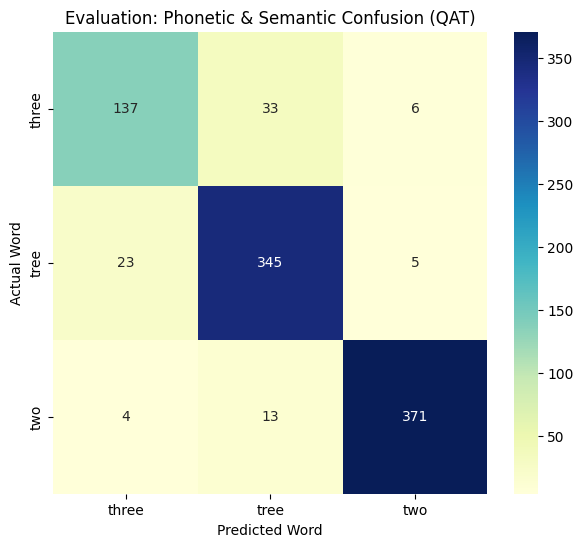

In [28]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="tensorflow")

labels = ['down', 'go', 'left', 'no', 'off', 'on', 'right', 'stop', 'up', 'yes', 'three', 'tree', 'two']

model_file = os.path.join(results_path, 'Model_B_Separable_qat.tflite')
interpreter = tf.lite.Interpreter(model_path=model_file)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

y_pred = []
for i in range(len(X_test)):
    sample = X_test[i]                               # shape: (H, W)
    input_data = sample[np.newaxis, ..., np.newaxis] # shape: (1, H, W, 1)
    input_data = input_data.astype(np.float32)
    interpreter.set_tensor(input_details['index'], input_data)
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details['index'])
    y_pred.append(np.argmax(output_data))

y_pred = np.array(y_pred)
print(" Final predictions generated for Model B QAT.")

# Calculate
targets = ['three', 'tree', 'two']
cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])


# Plot
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=targets, yticklabels=targets)
plt.title('Evaluation: Phonetic & Semantic Confusion (QAT)')
plt.ylabel('Actual Word')
plt.xlabel('Predicted Word')
plt.savefig(os.path.join(results_path, 'heatmap_qat.png'), dpi=300)
plt.show()

## Key Observations(Model B)
### The QAT model achieved higher classification accuracy (91.04%) than the PTQ model (88.37%), demonstrating superior robustness under low-precision inference.
### Analysis of the confusion matrices shows that QAT significantly reduced misclassification between the phonetically similar classes “three” and “tree”. In particular, errors where “tree” was incorrectly predicted as “three” decreased from 66 samples in PTQ to 23 samples in QAT. This improvement occurs because Quantization-Aware Training exposes the network to simulated int8 quantization effects during training, allowing the model to adapt its feature representations to low-precision constraints.
### As a result, QAT preserves subtle acoustic distinctions more effectively than Post-Training Quantization, leading to improved phonetic discrimination and overall classification performance.




